In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.display.float_format = '{:.2f}'.format


In [129]:
df_original = pd.read_csv('train.csv')

Conjunto de dados macro 

In [116]:
print(df_original.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL        65.00     8450   Pave   NaN      Reg   
1   2          20       RL        80.00     9600   Pave   NaN      Reg   
2   3          60       RL        68.00    11250   Pave   NaN      IR1   
3   4          70       RL        60.00     9550   Pave   NaN      IR1   
4   5          60       RL        84.00    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
1         Lvl    AllPub       FR2       Gtl      Veenker      Feedr   
2         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
3         Lvl    AllPub    Corner       Gtl      Crawfor       Norm   
4         Lvl    AllPub       FR2       Gtl      NoRidge       Norm   

  Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  \
0       Norm     1Fam     2Story            7          

In [119]:
df_original.shape

(1460, 81)

In [122]:
print(df_original.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Verificação de dados nulos

In [123]:
print(df_original.isnull().sum())

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

Valores únicos de cada variável 

In [124]:
valores_unicos = []
for i in df_original.columns[0:80].tolist():
    print(i, ':', len(df_original[i].astype(str).value_counts()))
    valores_unicos.append(len(df_original[i].astype(str).value_counts()))

Id : 1460
MSSubClass : 15
MSZoning : 5
LotFrontage : 111
LotArea : 1073
Street : 2
Alley : 3
LotShape : 4
LandContour : 4
Utilities : 2
LotConfig : 5
LandSlope : 3
Neighborhood : 25
Condition1 : 9
Condition2 : 8
BldgType : 5
HouseStyle : 8
OverallQual : 10
OverallCond : 9
YearBuilt : 112
YearRemodAdd : 61
RoofStyle : 6
RoofMatl : 8
Exterior1st : 15
Exterior2nd : 16
MasVnrType : 4
MasVnrArea : 328
ExterQual : 4
ExterCond : 5
Foundation : 6
BsmtQual : 5
BsmtCond : 5
BsmtExposure : 5
BsmtFinType1 : 7
BsmtFinSF1 : 637
BsmtFinType2 : 7
BsmtFinSF2 : 144
BsmtUnfSF : 780
TotalBsmtSF : 721
Heating : 6
HeatingQC : 5
CentralAir : 2
Electrical : 6
1stFlrSF : 753
2ndFlrSF : 417
LowQualFinSF : 24
GrLivArea : 861
BsmtFullBath : 4
BsmtHalfBath : 3
FullBath : 4
HalfBath : 3
BedroomAbvGr : 8
KitchenAbvGr : 4
KitchenQual : 4
TotRmsAbvGrd : 12
Functional : 7
Fireplaces : 4
FireplaceQu : 6
GarageType : 7
GarageYrBlt : 98
GarageFinish : 4
GarageCars : 5
GarageArea : 441
GarageQual : 6
GarageCond : 6
PavedDr

Correlação do Preço de Venda com variáveis qualitativas

In [131]:
print(df_original['SalePrice'].describe())

count     1460.00
mean    180921.20
std      79442.50
min      34900.00
25%     129975.00
50%     163000.00
75%     214000.00
max     755000.00
Name: SalePrice, dtype: float64


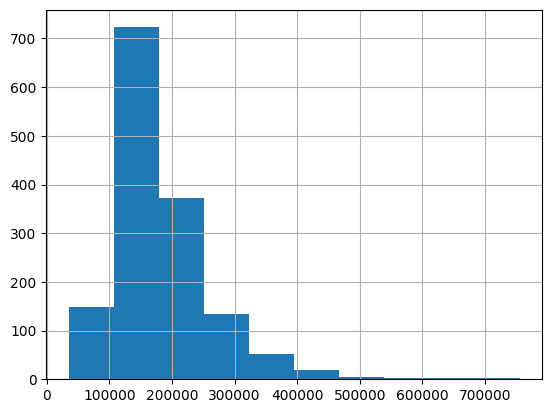

In [133]:
df_original['SalePrice'].hist()
xlabel = 'Preco'

In [140]:
df_original.groupby('Neighborhood')['SalePrice'].mean()

Neighborhood
Blmngtn   194870.88
Blueste   137500.00
BrDale    104493.75
BrkSide   124834.05
ClearCr   212565.43
CollgCr   197965.77
Crawfor   210624.73
Edwards   128219.70
Gilbert   192854.51
IDOTRR    100123.78
MeadowV    98576.47
Mitchel   156270.12
NAmes     145847.08
NPkVill   142694.44
NWAmes    189050.07
NoRidge   335295.32
NridgHt   316270.62
OldTown   128225.30
SWISU     142591.36
Sawyer    136793.14
SawyerW   186555.80
Somerst   225379.84
StoneBr   310499.00
Timber    242247.45
Veenker   238772.73
Name: SalePrice, dtype: float64

<Axes: ylabel='Neighborhood'>

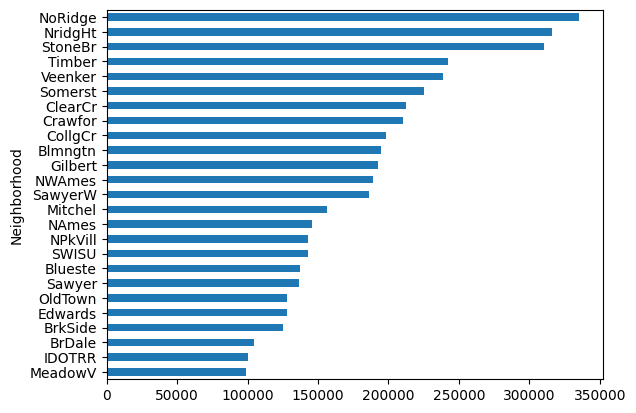

In [142]:
(
    df_original.groupby('Neighborhood')['SalePrice']
    .mean()
    .sort_values()
    .plot(kind='barh')
)

In [167]:
df_original.groupby('ExterQual')['SalePrice'].mean()

ExterQual
Ex   367360.96
Fa    87985.21
Gd   231633.51
TA   144341.31
Name: SalePrice, dtype: float64

<Axes: xlabel='ExterQual'>

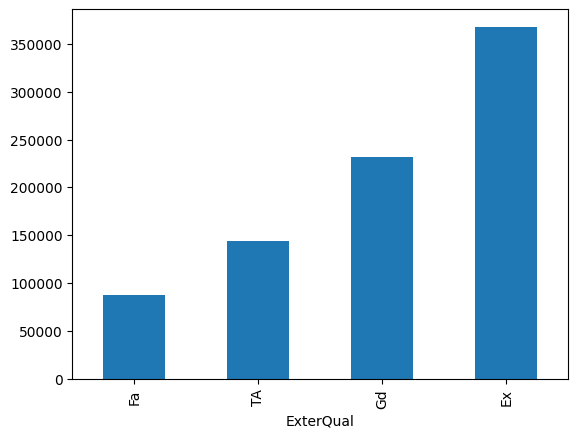

In [171]:
(
    df_original.groupby('ExterQual')['SalePrice']
    .mean()
    .sort_values()
    .plot(kind='bar')
)

In [168]:
df_original.groupby('KitchenQual')['SalePrice'].mean()

KitchenQual
Ex   328554.67
Fa   105565.21
Gd   212116.02
TA   139962.51
Name: SalePrice, dtype: float64

<Axes: xlabel='KitchenQual'>

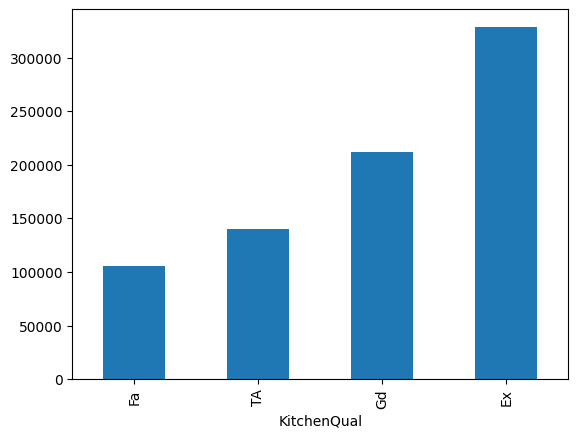

In [172]:
(
    df_original.groupby('KitchenQual')['SalePrice']
    .mean()
    .sort_values()
    .plot(kind='bar')
)

In [169]:
df_original.groupby('BsmtQual')['SalePrice'].mean()

BsmtQual
Ex   327041.04
Fa   115692.03
Gd   202688.48
TA   140759.82
Name: SalePrice, dtype: float64

<Axes: xlabel='BsmtQual'>

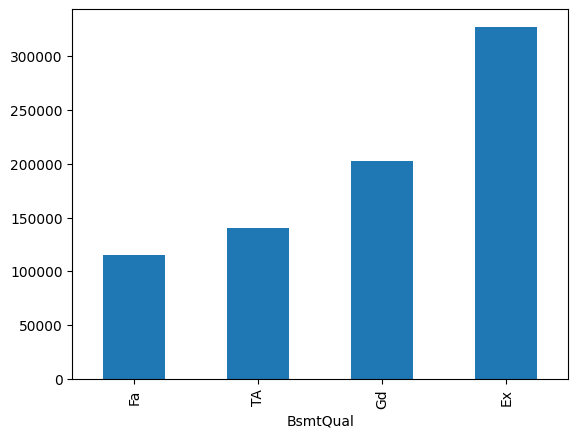

In [174]:
(
    df_original.groupby('BsmtQual')['SalePrice']
    .mean()
    .sort_values()
    .plot(kind='bar')
)

Correlação do Preço de Venda com variáveis qualitativas

In [175]:
num_cols = df_original.select_dtypes(include=['int64','float64'])

In [177]:
corr = num_cols.corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(10))

SalePrice      1.00
OverallQual    0.79
GrLivArea      0.71
GarageCars     0.64
GarageArea     0.62
TotalBsmtSF    0.61
1stFlrSF       0.61
FullBath       0.56
TotRmsAbvGrd   0.53
YearBuilt      0.52
Name: SalePrice, dtype: float64


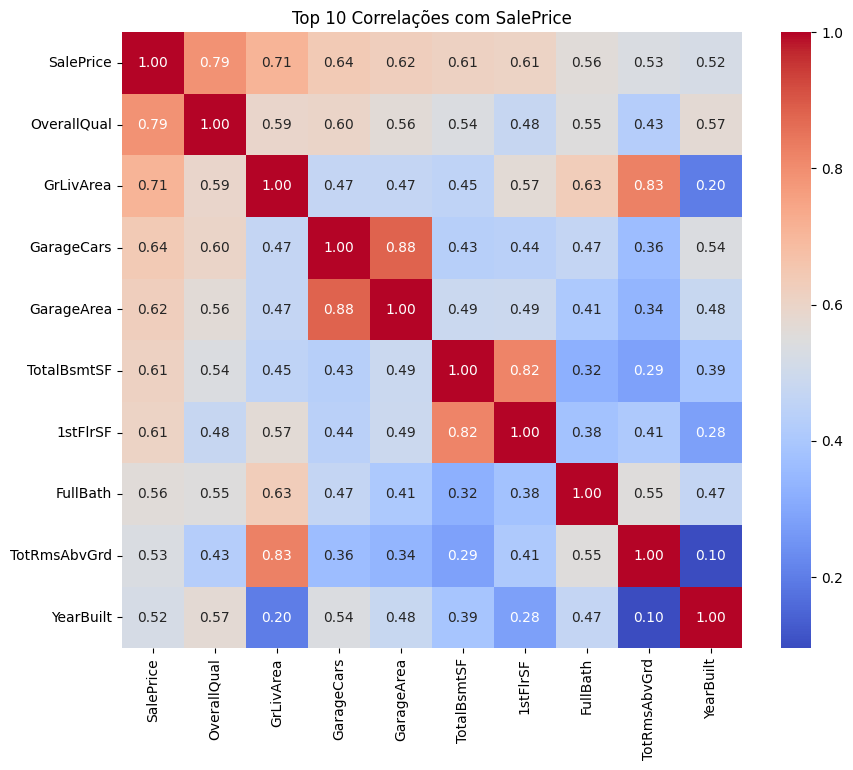

In [178]:
plt.figure(figsize=(10, 8))
top_features = corr.index[:10]
sns.heatmap(df_original[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 Correlações com SalePrice')
plt.show()